<a href="https://colab.research.google.com/github/MadhukarReddyAare/Edvancer_Deep_Learning_Projects/blob/Projects_Code_Files/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
from keras.applications.resnet50 import ResNet50
from keras.layers import Dense, LSTM, Embedding, RepeatVector, Concatenate, Activation, TimeDistributed
from keras.models import Sequential, Model
from keras.preprocessing import image, sequence
from tensorflow.keras.utils import to_categorical
from IPython.display import Image, display

In [2]:
# Download and unzip dataset
!wget https://www.dropbox.com/sh/q4dehgdtbo0b6vt/AABFoMwAxqEQWQnl_xQYY2fsa?dl=0

--2025-01-23 09:14:47--  https://www.dropbox.com/sh/q4dehgdtbo0b6vt/AABFoMwAxqEQWQnl_xQYY2fsa?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fo/bzncnlk9ufjde4t7w0q4k/AHQ8GDVQ5ANUg7oNBfvgcdE?rlkey=cdg8cc8hdfsazsj6rmvpqwrd1&dl=0 [following]
--2025-01-23 09:14:47--  https://www.dropbox.com/scl/fo/bzncnlk9ufjde4t7w0q4k/AHQ8GDVQ5ANUg7oNBfvgcdE?rlkey=cdg8cc8hdfsazsj6rmvpqwrd1&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5bad8bc309ad70369bc4b7d885.dl.dropboxusercontent.com/zip_download_get/CGHOEXGr_rnIdLTYesyIVb9-UW4cQWlsNChXJAZcnlJanoJ8ZIXyhEExLfd4ErVaLBOo8gl7SVreCk9G1eoVg_i1Xg0eno4Hpa6caZrDC2sz0Q# [following]
--2025-01-23 09:14:50--  https://uc5bad8bc309ad70369bc4b7d885.dl.dropboxusercontent.com/zip_

In [3]:
!unzip /content/AABFoMwAxqEQWQnl_xQYY2fsa?dl=0

Streaming output truncated to the last 5000 lines.
 extracting: Flicker8k_Dataset/2083778090_3aecaa11cc.jpg  
 extracting: Flicker8k_Dataset/2089555297_95cf001fa7.jpg  
 extracting: Flicker8k_Dataset/2195887578_3ba2f29b48.jpg  
 extracting: Flicker8k_Dataset/2230067846_74046b89d3.jpg  
 extracting: Flicker8k_Dataset/2264316030_600e55748d.jpg  
 extracting: Flicker8k_Dataset/2271671533_7538ccd556.jpg  
 extracting: Flicker8k_Dataset/2420730259_86e7f8a815.jpg  
 extracting: Flicker8k_Dataset/2602085456_d1beebcb29.jpg  
 extracting: Flicker8k_Dataset/2687672606_275169c35d.jpg  
 extracting: Flicker8k_Dataset/2750867389_4b815f793a.jpg  
 extracting: Flicker8k_Dataset/2751694538_fffa3d307d.jpg  
 extracting: Flicker8k_Dataset/2809793070_1a3387cd6e.jpg  
 extracting: Flicker8k_Dataset/2871962580_b85ce502ba.jpg  
 extracting: Flicker8k_Dataset/2929272606_2a5923b38e.jpg  
 extracting: Flicker8k_Dataset/3015898903_70bebb8903.jpg  
 extracting: Flicker8k_Dataset/3018847610_0bf4d7e43d.jpg  
 extr

In [4]:
# Paths
images_path = '/content/Flicker8k_Dataset/'
captions_path = '/content/Flickr8k_text/Flickr8k.token.txt'
train_path = '/content/Flickr8k_text/Flickr_8k.trainImages.txt'
val_path = '/content/Flickr8k_text/Flickr_8k.devImages.txt'
test_path = '/content/Flickr8k_text/Flickr_8k.testImages.txt'

In [5]:
# Load captions and image IDs
def load_data(path):
    with open(path, 'r') as file:
        return file.read().split("\n")

captions = load_data(captions_path)
x_train = load_data(train_path)
x_val = load_data(val_path)
x_test = load_data(test_path)

In [6]:
# Create a dictionary for image captions
tokens = {}
for caption in captions:
    if caption:
        img_id, caption_text = caption.split("#")[0], caption.split("#")[1][2:]
        tokens.setdefault(img_id, []).append(caption_text)

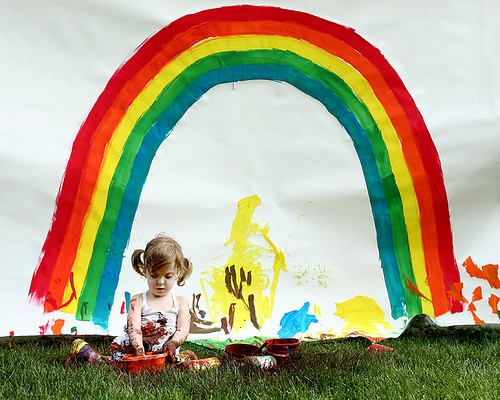

A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
A little girl is sitting in front of a large painted rainbow .
A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
There is a girl with pigtails sitting in front of a rainbow painting .
Young girl with pigtails painting outside in the grass .


In [7]:
# Display an image and its captions
def display_image_with_captions(img_id):
    img_path = os.path.join(images_path, img_id)
    display(Image(filename=img_path))
    for caption in tokens[img_id]:
        print(caption)

display_image_with_captions(captions[10].split("#")[0])

In [8]:
# Create datasets
def create_dataset(file_path, img_ids):
    with open(file_path, 'wb') as file:
        file.write(b"image_id\tcaptions\n")
        for img_id in img_ids:
            if img_id:
                for caption in tokens[img_id]:
                    file.write(f"{img_id}\t {caption} \n".encode())

create_dataset('/content/flickr_8k_train_dataset.txt', x_train)
create_dataset('/content/flickr_8k_val_dataset.txt', x_val)
create_dataset('/content/flickr_8k_test_dataset.txt', x_test)

In [9]:
# Load ResNet50 model
resnet_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3), pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# Preprocess images
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224, 3))
    img = image.img_to_array(img)
    return np.expand_dims(img, axis=0)

In [11]:
# Encode images
def encode_images(img_ids, model, limit=None):
    encoded_images = {}
    for i, img_id in enumerate(img_ids):
        if img_id and (limit is None or i < limit):
            img_path = os.path.join(images_path, img_id)
            img = preprocess_image(img_path)
            encoded_images[img_id] = model.predict(img).reshape(2048)
    return encoded_images

train_data = encode_images(x_train, resnet_model, limit=3000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [12]:
# Save encoded images
with open("/content/train_encoded_images.pkl", "wb") as file:
    pickle.dump(train_data, file)

In [13]:
# Load dataset into DataFrame
df = pd.read_csv("/content/flickr_8k_train_dataset.txt", delimiter='\t')
sentences = df['captions'].tolist()

In [14]:
# Create vocabulary
words = [sentence.split() for sentence in sentences]
unique_words = set(word for sentence in words for word in sentence)
vocab_size = len(unique_words)

word_2_indices = {word: idx for idx, word in enumerate(unique_words)}
indices_2_word = {idx: word for word, idx in word_2_indices.items()}

In [15]:
# Save vocabulary
with open("/content/word_2_indices.pkl", "wb") as file:
    pickle.dump(word_2_indices, file)
with open("/content/indices_2_word.pkl", "wb") as file:
    pickle.dump(indices_2_word, file)

In [16]:
# Prepare sequences
max_len = max(len(sentence.split()) for sentence in sentences)
padded_sequences, subsequent_words = [], []

In [ ]:
for sentence in sentences:
    text = [word_2_indices[word] for word in sentence.split()]
    for i in range(1, len(text)):
        partial_seq = text[:i]
        next_word = text[i]
        padded_sequences.append(sequence.pad_sequences([partial_seq], maxlen=max_len, padding='post')[0])
        subsequent_words.append(to_categorical(next_word, num_classes=vocab_size))

In [ ]:
padded_sequences = np.array(padded_sequences)
subsequent_words = np.array(subsequent_words)

In [ ]:
# Save sequences
np.save("/content/captions.npy", padded_sequences)
np.save("/content/next_words.npy", subsequent_words)

In [ ]:
# Load encoded images
with open('/content/train_encoded_images.pkl', 'rb') as file:
    encoded_images = pickle.load(file)

In [ ]:
# Prepare image data
image_data = np.array([encoded_images[img_id] for img_id in df['image_id'] if img_id in encoded_images])

In [ ]:
# Save image data
np.save("/content/images.npy", image_data)

In [ ]:
# Define models
embedding_size = 128

image_model = Sequential([
    Dense(embedding_size, input_shape=(2048,), activation='relu'),
    RepeatVector(max_len)
])

language_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=max_len),
    LSTM(256, return_sequences=True),
    TimeDistributed(Dense(embedding_size))
])

combined_input = Concatenate()([image_model.output, language_model.output])
x = LSTM(128, return_sequences=True)(combined_input)
x = LSTM(512, return_sequences=False)(x)
x = Dense(vocab_size)(x)
output = Activation('softmax')(x)

In [ ]:
model = Model(inputs=[image_model.input, language_model.input], outputs=output)
model.compile(loss='categorical_crossentropy', optimizer='RMSprop', metrics=['accuracy'])

In [ ]:
# Train model
model.fit([image_data, padded_sequences], subsequent_words, batch_size=512, epochs=200)

In [ ]:
# Save model
model.save_weights("/content/model_weights.h5")
model.save("/content/model.h5")

In [ ]:
# Predict captions
def predict_caption(image, model, max_len=40):
    start_word = [""]
    while True:
        par_caps = [word_2_indices[word] for word in start_word]
        par_caps = sequence.pad_sequences([par_caps], maxlen=max_len, padding='post')
        preds = model.predict([np.array([image]), np.array(par_caps)])
        word_pred = indices_2_word[np.argmax(preds[0])]
        start_word.append(word_pred)
        if word_pred == "" or len(start_word) > max_len:
            break
    return ' '.join(start_word[1:-1])

In [ ]:
# Test prediction
test_img_path = "/content/Flicker8k_Dataset/1453366750_6e8cf601bf.jpg"
test_img = preprocess_image(test_img_path)
encoded_test_img = resnet_model.predict(test_img).reshape(2048)
caption = predict_caption(encoded_test_img, model)

In [ ]:
# Display image and predicted caption
display(image.load_img(test_img_path))
print(caption)